In [4]:
from scipy import integrate
import numpy as np, matplotlib.pyplot as plt

c = 2.99792458e10  # cm/s
Msun = 1.989e33  # g
day = 24*3600  # s
pi = 3.14159265359
tau_Ni = 8.8*day  # s
tau_Co = 111.3*day  # s
e_Ni = 3.9e10  # erg/s/g
e_Co = 6.78e9  # erg/s/g

In [5]:
Mej = 10*Msun    # mass of ejecta
M_Ni= 0.1*Msun   # mass of 56Ni
Rmax0 = 1e14 # cm
Ek = 1*1e51 # erg
kappa = 0.2  # cm^2/g
x0 = 0.1
delta = 0
n = 10
Im = x0**3/(3-delta)+(x0**n-x0**3)/(3-n)
Ik = x0**5/(5-delta)+(x0**n-x0**5)/(5-n)
rho0 = Mej/(4*pi*Im*Rmax0**3)  # g/cm^3
v_max = (2*Ek*Im/(Mej*Ik))**(1/2)   # cm/s
beta = 13.8
tau_m = (2*kappa*Mej/(beta*c*v_max))**(1/2)

In [6]:
def L_rad(t):     ## Ni衰变释放光度 
    return M_Ni*((e_Ni-e_Co)*np.exp(-t/tau_Ni) + e_Co*np.exp(-t/tau_Co))

L_Ni0 = M_Ni*(e_Ni-e_Co)
y = tau_m/tau_Ni
z = tau_m/tau_Co

def f_quad(xp):
    return xp*np.exp(xp*xp/2.0)*(np.exp(-xp*y) + e_Co/(e_Ni-e_Co) * np.exp(-xp*z) )

def Lamd_x(x):
    return np.exp(-x*x/2.0)*integrate.quad(f_quad,0,x)[0]

def L_bol(t):
    x = t/tau_m
    return L_Ni0*Lamd_x(x)


L_bol_vel = np.vectorize(L_bol)    


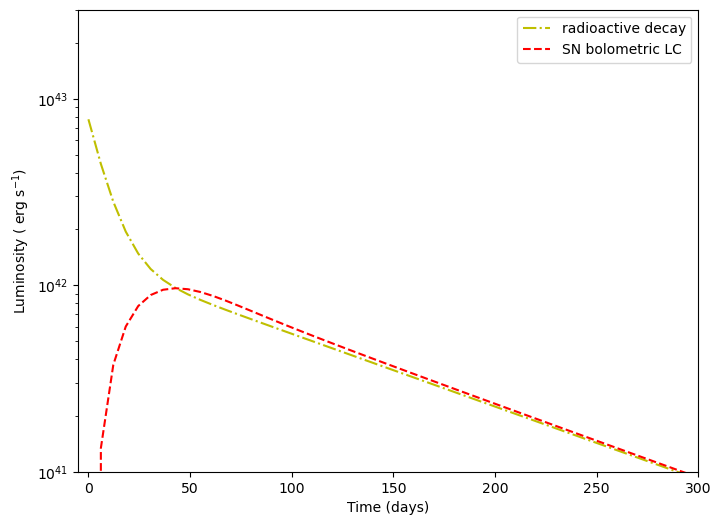

In [7]:
t_s = np.linspace(0,300)*day
fig = plt.figure(figsize=(8, 6))
plt.plot(t_s/day, L_rad(t_s),'y-.', label='radioactive decay')
plt.plot(t_s/day, L_bol_vel(t_s),'r--', label='SN bolometric LC')
# # plt.plot(t/day, L_Ni, label='Ni')
# plt.plot(t/day, L_Co, label='Co')
# plt.plot(t/day, Lbol, label='bol')
plt.xlabel('Time (days)')
plt.ylabel(r'Luminosity ( erg s$^{-1}$)')
plt.legend()
plt.ylim(1e41, 3e43)
plt.xlim(-5, 300)
plt.yscale('log')
plt.show()


## 微分方程的方法

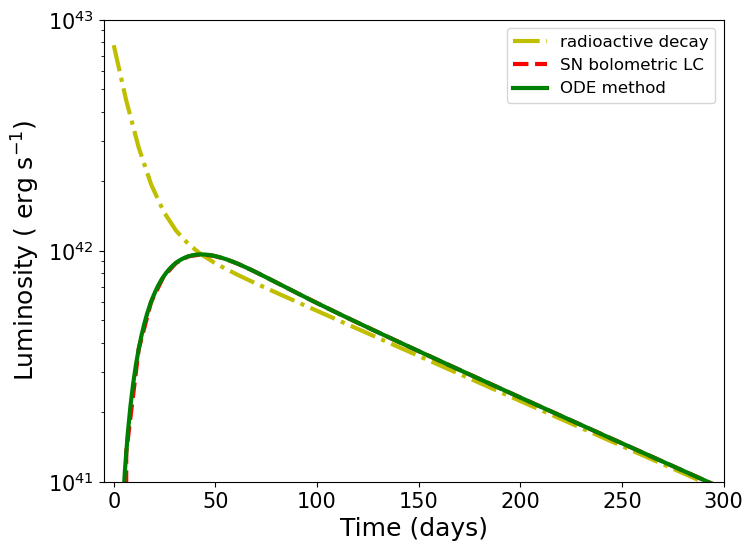

In [8]:
from scipy.integrate import odeint
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

L_Ni0 = M_Ni*(e_Ni-e_Co)
y = tau_m/tau_Ni
z = tau_m/tau_Co

def f(x):
    return np.exp(-x*y) + e_Co/(e_Ni-e_Co) * np.exp(-x*z)
    
# 定义一个函数，表示待解的ODE
def myODE(xi, x):
    dxidx = x*f(x)-x*xi  # 这是一个简单的一阶ODE的例子
    return dxidx

# 设置初始条件和时间步长
xi0 = 0.00001
x0 = 0
dx = 0.05
num_steps = 300

# 初始化数组
x = np.zeros(num_steps + 1)
xi = np.zeros(num_steps + 1)

# 进行数值积分
x[0] = x0
xi[0] = xi0
for i in range(num_steps):
    k1 = myODE(xi[i], x[i])
    k2 = myODE(xi[i] + 0.5 * dx * k1, x[i] + 0.5 * dx)
    k3 = myODE(xi[i] + 0.5 * dx * k2, x[i] + 0.5 * dx)
    k4 = myODE(xi[i] + dx * k3, x[i] + dx)
    
    xi[i+1] = xi[i] + (dx / 6) * (k1 + 2*k2 + 2*k3 + k4)
    x[i+1] = x[i] + dx

    
# 绘制结果
t_s = np.linspace(0,300)*day
fig = plt.figure(figsize=(8, 6))
plt.plot(t_s/day, L_rad(t_s),'y-.', lw=3,label='radioactive decay')
plt.plot(t_s/day, L_bol_vel(t_s),'r--', lw=3,label='SN bolometric LC')
plt.plot(tau_m*x/day, L_Ni0*xi,'g',lw=3,label='ODE method')
plt.xlabel('Time (days)',fontsize=18)
plt.ylabel(r'Luminosity ( erg s$^{-1}$)',fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=12)
plt.ylim(1e41, 1e43)
plt.xlim(-5, 300)
plt.yscale('log')
plt.show()
